In [1]:
!pip install scikit-learn torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import copy
import time

# Check device — GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class TeacherCNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=1, channels=[64,128,256,512]):
        super().__init__()
        self.channels = channels
        layers = []
        c_in = in_channels
        for c_out in channels:
            layers += [
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            ]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.classifier = None  # built dynamically in forward
        self.num_classes = num_classes
        self._fc = None

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        if self._fc is None:
            self._fc = nn.Linear(x.shape[1], self.num_classes).to(x.device)
        return self._fc(x)

def make_teacher(num_classes=10, in_channels=1, channels=[64,128,256,512]):
    model = TeacherCNN(num_classes, in_channels, channels).to(device)
    # Trigger fc creation with a dummy forward pass
    dummy_input_size = 32 if in_channels == 3 else 28
    with torch.no_grad():
        model(torch.zeros(1, in_channels, dummy_input_size, dummy_input_size).to(device))
    return model

print("Teacher CNN defined.")

Teacher CNN defined.


In [3]:
class AttentionMLP(nn.Module):
    """
    Two-layer MLP: Ci -> Ci//2 -> Ci with ReLU + Sigmoid
    Maps mean activation stats to per-filter importance scores in [0,1].
    """
    def __init__(self, num_filters):
        super().__init__()
        hidden = max(num_filters // 2, 1)
        self.net = nn.Sequential(
            nn.Linear(num_filters, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_filters),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print("AttentionMLP defined.")

AttentionMLP defined.


In [4]:
def get_conv_layers(model):
    """Return all Conv2d layers in order."""
    return [m for m in model.modules() if isinstance(m, nn.Conv2d)]

def get_conv_bn_pairs(model):
    """
    Return list of (conv, bn) tuples for each conv layer that is
    immediately followed by a BatchNorm2d in the features block.
    """
    pairs = []
    mods = list(model.features.children())
    for i, m in enumerate(mods):
        if isinstance(m, nn.Conv2d):
            bn = mods[i+1] if i+1 < len(mods) and isinstance(mods[i+1], nn.BatchNorm2d) else None
            pairs.append((m, bn))
    return pairs


def train_attention_modules(teacher, dataloader,
                             tattn=20, lr=0.001, lam=0.1):
    """
    Step 1 & 2: Initialize and train one AttentionMLP per conv layer.
    Uses a single mini-batch per epoch (paper Section 3.1 & Algorithm 1).
    Returns list of trained AttentionMLPs and their attention scores.
    """
    teacher.eval()
    pairs = get_conv_bn_pairs(teacher)
    n_layers = len(pairs)

    # Build one AttentionMLP per layer
    attention_mlps = [AttentionMLP(pairs[i][0].out_channels).to(device)
                      for i in range(n_layers)]
    optimizer = optim.Adam(
        [p for mlp in attention_mlps for p in mlp.parameters()], lr=lr
    )

    print(f"Training {n_layers} AttentionMLPs for {tattn} epochs...")
    for epoch in range(tattn):
        # Sample a single mini-batch (paper uses B=128)
        batch_X, batch_y = next(iter(dataloader))
        batch_X = batch_X.to(device)

        # Forward through teacher, collecting activations layer by layer
        alphas = []
        x = batch_X
        mods = list(teacher.features.children())
        layer_idx = 0
        for mod in mods:
            x = mod(x)
            if isinstance(mod, nn.BatchNorm2d) and layer_idx < n_layers:
                # Mean pool over batch, H, W → shape (Ci,)
                s = x.mean(dim=[0, 2, 3])           # Eq. 3 in paper
                alpha = attention_mlps[layer_idx](s.unsqueeze(0)).squeeze(0)
                alphas.append(alpha)
                layer_idx += 1

        # Attention loss: L1 sparsity + variance diversity (Eq. 6)
        loss = sum(
            alpha.norm(1) + lam * alpha.var()
            for alpha in alphas
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{tattn} | Attn Loss: {loss.item():.4f}")

    # Step 3: Compute final attention scores on a fresh mini-batch
    batch_X, _ = next(iter(dataloader))
    batch_X = batch_X.to(device)
    final_scores = []
    with torch.no_grad():
        x = batch_X
        mods = list(teacher.features.children())
        layer_idx = 0
        for mod in mods:
            x = mod(x)
            if isinstance(mod, nn.BatchNorm2d) and layer_idx < n_layers:
                s = x.mean(dim=[0, 2, 3])
                alpha = attention_mlps[layer_idx](s.unsqueeze(0)).squeeze(0)
                final_scores.append(alpha.cpu().numpy())
                layer_idx += 1

    return attention_mlps, final_scores


def select_filters(scores, compression_ratio=0.5):
    """
    Step 4: Select top-k filters per layer (Eq. 7 & 8).
    Returns list of index arrays (one per layer).
    """
    selected = []
    for alpha in scores:
        ci = len(alpha)
        ki = max(1, int((1 - compression_ratio) * ci))   # Eq. 7
        top_k_idx = np.argsort(alpha)[::-1][:ki]          # Eq. 8
        selected.append(np.sort(top_k_idx))
    return selected


def build_student(teacher, selected_indices):
    """
    Step 5 & 6: Construct compressed student and transfer weights.
    Mirrors teacher connectivity with reduced channel dims.
    """
    student = copy.deepcopy(teacher)
    mods = list(student.features.children())
    pair_idx = 0

    prev_indices = None  # tracks which input channels the previous layer kept

    for i, mod in enumerate(mods):
        if isinstance(mod, nn.Conv2d):
            idx_out = selected_indices[pair_idx]     # filters to KEEP (output)
            idx_in  = prev_indices                   # filters kept from prev layer

            # Slice output filters
            mod.weight.data = mod.weight.data[idx_out]
            if mod.bias is not None:
                mod.bias.data = mod.bias.data[idx_out]

            # Slice input channels (skip for first layer — input is RGB/greyscale)
            if idx_in is not None:
                mod.weight.data = mod.weight.data[:, idx_in]

            mod.out_channels = len(idx_out)
            mod.in_channels  = mod.weight.data.shape[1]

            prev_indices = idx_out
            pair_idx += 1

        elif isinstance(mod, nn.BatchNorm2d) and pair_idx > 0:
            idx = selected_indices[pair_idx - 1]
            mod.weight.data    = mod.weight.data[idx]
            mod.bias.data      = mod.bias.data[idx]
            mod.running_mean   = mod.running_mean[idx]
            mod.running_var    = mod.running_var[idx]
            mod.num_features   = len(idx)

    # Fix the fully-connected layer for the new flattened size
    # Re-run a dummy forward to get correct fc input size
    student.eval()
    student._fc = None  # reset so it gets rebuilt
    dummy_size = 32 if student.features[0].in_channels == 3 else 28
    in_ch = student.features[0].in_channels
    with torch.no_grad():
        dummy = torch.zeros(1, in_ch, dummy_size, dummy_size).to(device)
        feats = student.features(dummy)
        flat_size = feats.flatten(1).shape[1]
    student._fc = nn.Linear(flat_size, teacher.num_classes).to(device)
    # Copy FC weights for the kept indices (best-effort)
    if prev_indices is not None and teacher._fc is not None:
        try:
            flat_prev = prev_indices  # last conv layer kept indices
            # The FC receives flattened spatial features; we can't perfectly
            # slice without knowing spatial dims, so we reinitialise FC fresh.
            pass
        except Exception:
            pass

    return student


def finetune_student(student, dataloader, epochs=50,
                     lr=0.001, task='classification'):
    """Step 7: Brief fine-tuning of the compressed student (Eq. 13)."""
    student.train()
    optimizer = optim.Adam(student.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    criterion = (nn.CrossEntropyLoss()
                 if task == 'classification'
                 else nn.MSELoss())

    print(f"Fine-tuning student for {epochs} epochs...")
    for epoch in range(epochs):
        total_loss = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = student(X)
            if task == 'regression':
                loss = criterion(out.squeeze(), y.float())
            else:
                loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            avg = total_loss / len(dataloader)
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")

    return student


def run_adsc(teacher, train_loader, compression_ratio=0.5,
             tattn=20, ft_epochs=50, task='classification'):
    """
    Full ADSC pipeline — wraps all 7 steps.
    Returns (student_model, selected_filter_indices, attention_scores)
    """
    print("=== ADSC: Step 2 — Train Attention Modules ===")
    _, scores = train_attention_modules(teacher, train_loader, tattn=tattn)

    print("\n=== ADSC: Step 4 — Select Filters ===")
    selected = select_filters(scores, compression_ratio)
    for i, idx in enumerate(selected):
        print(f"  Layer {i}: keeping {len(idx)} / {len(scores[i])} filters")

    print("\n=== ADSC: Step 5 & 6 — Build Student & Transfer Weights ===")
    student = build_student(teacher, selected)

    teacher_params = sum(p.numel() for p in teacher.parameters())
    student_params = sum(p.numel() for p in student.parameters())
    comp = (1 - student_params / teacher_params) * 100
    print(f"  Teacher params: {teacher_params:,}")
    print(f"  Student params: {student_params:,}")
    print(f"  Compression:    {comp:.1f}%")

    print("\n=== ADSC: Step 7 — Fine-tune Student ===")
    student = finetune_student(student, train_loader,
                               epochs=ft_epochs, task=task)

    return student, selected, scores

print("ADSC pipeline defined.")

ADSC pipeline defined.


In [5]:
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,),(0.3081,))])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True,
                                          download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False,
                                          download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader  = DataLoader(mnist_test,  batch_size=256, shuffle=False)

# --- Train Teacher ---
teacher = make_teacher(num_classes=10, in_channels=1)

def train_model(model, loader, epochs=20, task='classification'):
    model.train()
    opt = optim.Adam(model.parameters(), lr=0.001)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()
    for ep in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            out = model(X)
            loss = crit(out, y) if task == 'classification' else crit(out.squeeze(), y.float())
            loss.backward()
            opt.step()
        sch.step()
        if (ep+1) % 5 == 0:
            print(f"  Epoch {ep+1}/{epochs}")
    return model

def evaluate(model, loader, task='classification'):
    model.eval()
    correct, total, mse_sum = 0, 0, 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            if task == 'classification':
                pred = out.argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)
            else:
                mse_sum += ((out.squeeze() - y.float())**2).sum().item()
                total += y.size(0)
    if task == 'classification':
        return 100 * correct / total
    else:
        return mse_sum / total   # MSE

print("Training MNIST teacher (20 epochs)...")
train_model(teacher, train_loader, epochs=20)
teacher_acc = evaluate(teacher, test_loader)
print(f"\nTeacher Accuracy: {teacher_acc:.2f}%")

# --- Run ADSC ---
student, selected, scores = run_adsc(
    teacher, train_loader,
    compression_ratio=0.5,
    tattn=20,
    ft_epochs=50,
    task='classification'
)

student_acc = evaluate(student, test_loader)
t_params = sum(p.numel() for p in teacher.parameters())
s_params = sum(p.numel() for p in student.parameters())
comp = (1 - s_params/t_params)*100

print(f"\n{'='*45}")
print(f"  MNIST RESULTS")
print(f"  Teacher Accuracy : {teacher_acc:.2f}%")
print(f"  Student Accuracy : {student_acc:.2f}%")
print(f"  Accuracy Drop    : {teacher_acc - student_acc:.2f}%")
print(f"  Compression      : {comp:.1f}%")
print(f"  Teacher Params   : {t_params:,}")
print(f"  Student Params   : {s_params:,}")
print(f"{'='*45}")
print(f"Paper target: ~99.25% acc, ~50.9% compression, ~0.06% drop")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.4MB/s]


Training MNIST teacher (20 epochs)...
  Epoch 5/20
  Epoch 10/20
  Epoch 15/20
  Epoch 20/20

Teacher Accuracy: 99.55%
=== ADSC: Step 2 — Train Attention Modules ===
Training 4 AttentionMLPs for 20 epochs...
  Epoch 5/20 | Attn Loss: 465.8240
  Epoch 10/20 | Attn Loss: 441.2369
  Epoch 15/20 | Attn Loss: 400.7057
  Epoch 20/20 | Attn Loss: 363.0098

=== ADSC: Step 4 — Select Filters ===
  Layer 0: keeping 32 / 64 filters
  Layer 1: keeping 64 / 128 filters
  Layer 2: keeping 128 / 256 filters
  Layer 3: keeping 256 / 512 filters

=== ADSC: Step 5 & 6 — Build Student & Transfer Weights ===
  Teacher params: 1,556,874
  Student params: 391,370
  Compression:    74.9%

=== ADSC: Step 7 — Fine-tune Student ===
Fine-tuning student for 50 epochs...
  Epoch 10/50 | Loss: 0.0052
  Epoch 20/50 | Loss: 0.0000
  Epoch 30/50 | Loss: 0.0000
  Epoch 40/50 | Loss: 0.0000
  Epoch 50/50 | Loss: 0.0000

  MNIST RESULTS
  Teacher Accuracy : 99.55%
  Student Accuracy : 99.54%
  Accuracy Drop    : 0.01%
  

In [6]:
# Cell 6 — CIFAR-10 experiment

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

c10_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
c10_test  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)
c10_train_loader = DataLoader(c10_train, batch_size=128, shuffle=True,  num_workers=2)
c10_test_loader  = DataLoader(c10_test,  batch_size=256, shuffle=False, num_workers=2)

teacher_c10 = make_teacher(num_classes=10, in_channels=3)

print("Training CIFAR-10 teacher (20 epochs)...")
train_model(teacher_c10, c10_train_loader, epochs=20)
t_acc_c10 = evaluate(teacher_c10, c10_test_loader)
print(f"Teacher CIFAR-10 Accuracy: {t_acc_c10:.2f}%")

student_c10, _, _ = run_adsc(
    teacher_c10, c10_train_loader,
    compression_ratio=0.5,
    tattn=20,
    ft_epochs=50,
    task='classification'
)

s_acc_c10 = evaluate(student_c10, c10_test_loader)
t_p = sum(p.numel() for p in teacher_c10.parameters())
s_p = sum(p.numel() for p in student_c10.parameters())
comp_c10 = (1 - s_p/t_p)*100

print(f"\n{'='*45}")
print(f"  CIFAR-10 RESULTS")
print(f"  Teacher Accuracy : {t_acc_c10:.2f}%")
print(f"  Student Accuracy : {s_acc_c10:.2f}%")
print(f"  Accuracy Drop    : {t_acc_c10 - s_acc_c10:.2f}%")
print(f"  Compression      : {comp_c10:.1f}%")
print(f"{'='*45}")
print(f"Paper target: ~85.79% acc, ~51% compression, ~0.89% drop")

100%|██████████| 170M/170M [00:05<00:00, 29.3MB/s]


Training CIFAR-10 teacher (20 epochs)...
  Epoch 5/20
  Epoch 10/20
  Epoch 15/20
  Epoch 20/20
Teacher CIFAR-10 Accuracy: 87.67%
=== ADSC: Step 2 — Train Attention Modules ===
Training 4 AttentionMLPs for 20 epochs...
  Epoch 5/20 | Attn Loss: 441.2068
  Epoch 10/20 | Attn Loss: 329.8706
  Epoch 15/20 | Attn Loss: 208.8581
  Epoch 20/20 | Attn Loss: 126.1727

=== ADSC: Step 4 — Select Filters ===
  Layer 0: keeping 32 / 64 filters
  Layer 1: keeping 64 / 128 filters
  Layer 2: keeping 128 / 256 filters
  Layer 3: keeping 256 / 512 filters

=== ADSC: Step 5 & 6 — Build Student & Transfer Weights ===
  Teacher params: 1,573,386
  Student params: 399,626
  Compression:    74.6%

=== ADSC: Step 7 — Fine-tune Student ===
Fine-tuning student for 50 epochs...
  Epoch 10/50 | Loss: 0.3769
  Epoch 20/50 | Loss: 0.2688
  Epoch 30/50 | Loss: 0.1952
  Epoch 40/50 | Loss: 0.1465
  Epoch 50/50 | Loss: 0.1338

  CIFAR-10 RESULTS
  Teacher Accuracy : 87.67%
  Student Accuracy : 87.74%
  Accuracy Drop

In [14]:
import torch
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Load and prepare data
data = fetch_california_housing()
X, y = data.data.astype(np.float32), data.target.astype(np.float32)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_t = torch.tensor(X_tr).unsqueeze(-1)  # (N, 8, 1) for 1D conv
X_te_t = torch.tensor(X_te).unsqueeze(-1)
y_tr_t = torch.tensor(y_tr)
y_te_t = torch.tensor(y_te)

reg_train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                               batch_size=128, shuffle=True)
reg_test_loader = DataLoader(TensorDataset(X_te_t, y_te_t),
                               batch_size=256)


# 1D CNN for regression (adapted from paper Section 4)
class TeacherCNN1D(nn.Module):
    def __init__(self, channels=[64, 128, 256, 512]):
        super().__init__()
        self.channels = channels
        self.num_classes = 1
        layers = []
        c_in = 1  # Changed: Treat features as sequence length, so 1 input channel
        for c_out in channels:
            layers += [
                nn.Conv1d(c_in, c_out, kernel_size=1), # kernel_size=1 to apply to each feature position
                nn.BatchNorm1d(c_out),
                nn.ReLU(inplace=True),
            ]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self._fc = None

    def forward(self, x):
        # x: (B, 8, 1) -> (Batch, Num_Features, Dummy_Length)
        # We want (Batch, Channels=1, Length=Num_Features) for Conv1D
        x = x.transpose(1, 2)  # (B, 1, 8)
        # Removed the second transpose, as it was redundant and created (B, 8, 1)

        x = self.features(x)
        x = x.flatten(1)
        if self._fc is None:
            self._fc = nn.Linear(x.shape[1], 1).to(x.device)
        return self._fc(x)


# 1D-specific helper functions, adapted from cell zrNf-hp1IlgX
def get_conv_bn_pairs_1d(model):
    pairs = []
    mods = list(model.features.children())
    for i, m in enumerate(mods):
        if isinstance(m, nn.Conv1d):
            bn = mods[i+1] if i+1 < len(mods) and isinstance(mods[i+1], nn.BatchNorm1d) else None
            if bn: # Only include pairs where Conv1d is followed by BatchNorm1d
                pairs.append((m, bn))
    return pairs

def train_attention_modules_1d(teacher, dataloader, tattn=20, lr=0.001, lam=0.1):
    teacher.eval()
    pairs = get_conv_bn_pairs_1d(teacher)
    n_layers = len(pairs)

    attention_mlps = [AttentionMLP(pairs[i][0].out_channels).to(device)
                      for i in range(n_layers)]
    optimizer = optim.Adam(
        [p for mlp in attention_mlps for p in mlp.parameters()], lr=lr
    )

    print(f"Training {n_layers} AttentionMLPs for {tattn} epochs...")
    for epoch in range(tattn):
        batch_X, batch_y = next(iter(dataloader))
        batch_X = batch_X.to(device)
        batch_X = batch_X.transpose(1, 2) # Apply the same transpose as in TeacherCNN1D forward

        alphas = []
        x = batch_X
        mods = list(teacher.features.children())
        layer_idx = 0
        for mod in mods:
            x = mod(x)
            if isinstance(mod, nn.BatchNorm1d) and layer_idx < n_layers:
                s = x.mean(dim=[0, 2])           # Eq. 3 in paper (adapted for 1D input [B, C, L])
                alpha = attention_mlps[layer_idx](s.unsqueeze(0)).squeeze(0)
                alphas.append(alpha)
                layer_idx += 1

        loss = sum(
            alpha.norm(1) + lam * alpha.var()
            for alpha in alphas
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{tattn} | Attn Loss: {loss.item():.4f}")

    batch_X, _ = next(iter(dataloader))
    batch_X = batch_X.to(device)
    batch_X = batch_X.transpose(1, 2) # Apply the same transpose as in TeacherCNN1D forward
    final_scores = []
    with torch.no_grad():
        x = batch_X
        mods = list(teacher.features.children())
        layer_idx = 0
        for mod in mods:
            x = mod(x)
            if isinstance(mod, nn.BatchNorm1d) and layer_idx < n_layers:
                s = x.mean(dim=[0, 2])
                alpha = attention_mlps[layer_idx](s.unsqueeze(0)).squeeze(0)
                final_scores.append(alpha.cpu().numpy())
                layer_idx += 1

    return attention_mlps, final_scores

def build_student_1d(teacher, selected_indices):
    student = copy.deepcopy(teacher)
    mods = list(student.features.children())
    pair_idx = 0

    prev_indices = None

    for i, mod in enumerate(mods):
        if isinstance(mod, nn.Conv1d): # Changed from Conv2d
            idx_out = selected_indices[pair_idx]     # filters to KEEP (output)
            idx_in  = prev_indices                   # filters kept from prev layer

            # Slice output filters
            mod.weight.data = mod.weight.data[idx_out]
            if mod.bias is not None:
                mod.bias.data = mod.bias.data[idx_out]

            # Slice input channels (skip for first layer — input is RGB/greyscale)
            if idx_in is not None:
                mod.weight.data = mod.weight.data[:, idx_in]

            mod.out_channels = len(idx_out)
            mod.in_channels  = mod.weight.data.shape[1]

            prev_indices = idx_out
            pair_idx += 1

        elif isinstance(mod, nn.BatchNorm1d) and pair_idx > 0: # Changed from BatchNorm2d
            idx = selected_indices[pair_idx - 1]
            mod.weight.data    = mod.weight.data[idx]
            mod.bias.data      = mod.bias.data[idx]
            mod.running_mean   = mod.running_mean[idx]
            mod.running_var    = mod.running_var[idx]
            mod.num_features   = len(idx)

    student.eval()
    student._fc = None
    # For TeacherCNN1D, after transpose(1,2), input to features is (B, 1, 8)
    in_ch = student.features[0].in_channels
    dummy_length = 8 # The original number of features
    with torch.no_grad():
        dummy = torch.zeros(1, in_ch, dummy_length).to(device)
        feats = student.features(dummy)
        flat_size = feats.flatten(1).shape[1]
    student._fc = nn.Linear(flat_size, teacher.num_classes).to(device)
    # Copy FC weights for the kept indices (best-effort)
    if prev_indices is not None and teacher._fc is not None:
        try:
            flat_prev = prev_indices
            # The FC receives flattened spatial features; we can't perfectly
            # slice without knowing spatial dims, so we reinitialise FC fresh.
            pass
        except Exception:
            pass

    return student

teacher_reg = TeacherCNN1D().to(device)
# Warmup to build _fc
with torch.no_grad():
    teacher_reg(torch.zeros(1, 8, 1).to(device))

print("Training California Housing teacher (20 epochs)...")
train_model(teacher_reg, reg_train_loader, epochs=20, task='regression')

def eval_regression(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X).squeeze().cpu().numpy()
            preds.extend(out if out.ndim > 0 else [float(out)])
            targets.extend(y.numpy())
    preds, targets = np.array(preds), np.array(targets)
    r2 = r2_score(targets, preds)
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    return r2, mse, rmse

t_r2, t_mse, t_rmse = eval_regression(teacher_reg, reg_test_loader)
print(f"Teacher R²: {t_r2:.4f} | MSE: {t_mse:.4f} | RMSE: {t_rmse:.4f}")

# Note: run_adsc expects 2D conv; for regression use a simplified compression
# We'll manually do the compression steps for 1D case, using 1D-adapted functions
_, scores_reg = train_attention_modules_1d(teacher_reg, reg_train_loader, tattn=20)
selected_reg = select_filters(scores_reg, compression_ratio=0.5)
for i, idx in enumerate(selected_reg):
    print(f"  Layer {i}: keeping {len(idx)} / {len(scores_reg[i])} filters")

print("\n=== ADSC: Step 5 & 6 — Build Student & Transfer Weights (1D) ===")
student_reg = build_student_1d(teacher_reg, selected_reg)

teacher_reg_params = sum(p.numel() for p in teacher_reg.parameters())
student_reg_params = sum(p.numel() for p in student_reg.parameters())
comp_reg = (1 - student_reg_params / teacher_reg_params) * 100
print(f"  Teacher params: {teacher_reg_params:,}")
print(f"  Student params: {student_reg_params:,}")
print(f"  Compression:    {comp_reg:.1f}%")

print("\n=== ADSC: Step 7 — Fine-tune Student (1D) ===")
student_reg = finetune_student(student_reg, reg_train_loader,
                               epochs=50, task='regression')

s_r2, s_mse, s_rmse = eval_regression(student_reg, reg_test_loader)

print(f"\n{'='*45}")
print(f"  CALIFORNIA HOUSING RESULTS")
print(f"  Teacher R²   : {t_r2:.4f}")
print(f"  Student R²   : {s_r2:.4f}")
print(f"  Compression      : {comp_reg:.1f}%")
print(f"  Paper target : R² ~0.7605 (teacher), ADSC ~0.7448 with 65.7% compression")
print(f"  Note: 1D CNN adaption for Housing; see paper Table 3 for full comparison")
print(f"{'='*45}")

Training California Housing teacher (20 epochs)...
  Epoch 5/20
  Epoch 10/20
  Epoch 15/20
  Epoch 20/20
Teacher R²: 0.7198 | MSE: 0.2757 | RMSE: 0.5251
Training 4 AttentionMLPs for 20 epochs...
  Epoch 5/20 | Attn Loss: 471.7113
  Epoch 10/20 | Attn Loss: 450.9359
  Epoch 15/20 | Attn Loss: 415.3608
  Epoch 20/20 | Attn Loss: 369.3501
  Layer 0: keeping 32 / 64 filters
  Layer 1: keeping 64 / 128 filters
  Layer 2: keeping 128 / 256 filters
  Layer 3: keeping 256 / 512 filters

=== ADSC: Step 5 & 6 — Build Student & Transfer Weights (1D) ===
  Teacher params: 179,073
  Student params: 46,529
  Compression:    74.0%

=== ADSC: Step 7 — Fine-tune Student (1D) ===
Fine-tuning student for 50 epochs...
  Epoch 10/50 | Loss: 0.2824
  Epoch 20/50 | Loss: 0.2703
  Epoch 30/50 | Loss: 0.2598
  Epoch 40/50 | Loss: 0.2541
  Epoch 50/50 | Loss: 0.2513

  CALIFORNIA HOUSING RESULTS
  Teacher R²   : 0.7198
  Student R²   : 0.7137
  Compression      : 74.0%
  Paper target : R² ~0.7605 (teacher), AD

In [8]:
def evaluate_noisy(model, loader, sigma=0.1):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            X_noisy = X + sigma * torch.randn_like(X)
            pred = model(X_noisy).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

# Uses 'student' and 'teacher' from Step 5 (MNIST)
acc_clean   = evaluate(student, test_loader)
acc_noisy_1 = evaluate_noisy(student, test_loader, sigma=0.1)
acc_noisy_2 = evaluate_noisy(student, test_loader, sigma=0.2)

print(f"\n{'='*45}")
print(f"  ROBUSTNESS RESULTS (MNIST Student)")
print(f"  Clean Accuracy     : {acc_clean:.2f}%")
print(f"  Noisy (σ=0.1)     : {acc_noisy_1:.2f}%  (drop: {acc_clean-acc_noisy_1:.2f}%)")
print(f"  Noisy (σ=0.2)     : {acc_noisy_2:.2f}%  (drop: {acc_clean-acc_noisy_2:.2f}%)")
print(f"{'='*45}")
print(f"Paper target: drops of 0.07% (σ=0.1) and 0.02% (σ=0.2)")


  ROBUSTNESS RESULTS (MNIST Student)
  Clean Accuracy     : 99.54%
  Noisy (σ=0.1)     : 99.56%  (drop: -0.02%)
  Noisy (σ=0.2)     : 99.35%  (drop: 0.19%)
Paper target: drops of 0.07% (σ=0.1) and 0.02% (σ=0.2)


In [10]:
# Variant A: Without learnable attention (plain mean activation pruning)
print("=== Variant A: Without Learnable Attention (mean pruning) ===")
def mean_activation_scores(teacher, dataloader):
    """Simple mean activation — no MLP, no learning."""
    teacher.eval()
    pairs = get_conv_bn_pairs(teacher)
    scores = []
    X, _ = next(iter(dataloader))
    X = X.to(device)
    with torch.no_grad():
        x = X
        mods = list(teacher.features.children())
        layer_idx = 0
        for mod in mods:
            x = mod(x)
            if isinstance(mod, nn.BatchNorm2d) and layer_idx < len(pairs):
                s = x.mean(dim=[0,2,3]).cpu().numpy()
                scores.append(s)
                layer_idx += 1
    return scores

scores_noattn = mean_activation_scores(teacher, train_loader)
sel_noattn    = select_filters(scores_noattn, 0.5)
student_noattn = build_student(teacher, sel_noattn)
student_noattn = finetune_student(student_noattn, train_loader, epochs=50)
acc_noattn = evaluate(student_noattn, test_loader)
print(f"Without Learnable Attention Accuracy: {acc_noattn:.2f}% (paper: 99.17%)")

# Variant B: Global uniform compression instead of layer-wise
print("\n=== Variant B: Global Uniform Compression ===")
# Use a higher uniform ratio across all layers
scores_global = [scores[i] for i in range(len(scores))]   # reuse MNIST scores
sel_global = select_filters(scores_global, compression_ratio=0.62)  # ~62.7% compression
student_global = build_student(teacher, sel_global)
student_global = finetune_student(student_global, train_loader, epochs=50)
acc_global = evaluate(student_global, test_loader)
print(f"Global Compression Accuracy: {acc_global:.2f}% (paper: 99.23%)")

# Variant C: Full ADSC (already done in Step 5)
print(f"\nFull ADSC Accuracy: {student_acc:.2f}% (paper: 99.29%)")

print(f"\n{'='*50}")
print(f"  ABLATION SUMMARY")
print(f"  Without Learnable Attn : {acc_noattn:.2f}%")
print(f"  Global Compression     : {acc_global:.2f}%")
print(f"  Full ADSC              : {student_acc:.2f}%")
print(f"{'='*50}")

=== Variant A: Without Learnable Attention (mean pruning) ===
Fine-tuning student for 50 epochs...
  Epoch 10/50 | Loss: 0.0026
  Epoch 20/50 | Loss: 0.0000
  Epoch 30/50 | Loss: 0.0000
  Epoch 40/50 | Loss: 0.0000
  Epoch 50/50 | Loss: 0.0000
Without Learnable Attention Accuracy: 99.44% (paper: 99.17%)

=== Variant B: Global Uniform Compression ===
Fine-tuning student for 50 epochs...
  Epoch 10/50 | Loss: 0.0029
  Epoch 20/50 | Loss: 0.0000
  Epoch 30/50 | Loss: 0.0000
  Epoch 40/50 | Loss: 0.0000
  Epoch 50/50 | Loss: 0.0000
Global Compression Accuracy: 99.50% (paper: 99.23%)

Full ADSC Accuracy: 99.54% (paper: 99.29%)

  ABLATION SUMMARY
  Without Learnable Attn : 99.44%
  Global Compression     : 99.50%
  Full ADSC              : 99.54%


In [11]:
import os, io

def model_size_mb(model):
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.tell() / (1024**2)

# Measure ADSC total time (re-run a quick version)
t_start = time.time()
student_timed, _, _ = run_adsc(
    teacher, train_loader,
    compression_ratio=0.5,
    tattn=20, ft_epochs=15,    # reduce for timing demo
    task='classification'
)
adsc_time = time.time() - t_start

teacher_size = model_size_mb(teacher)
student_size = model_size_mb(student_timed)

print(f"\n{'='*45}")
print(f"  COMPUTATIONAL OVERHEAD (MNIST, 15 FT epochs)")
print(f"  ADSC Total Time  : {adsc_time:.1f}s")
print(f"  Teacher Size     : {teacher_size:.2f} MB")
print(f"  Student Size     : {student_size:.2f} MB")
print(f"  Size Reduction   : {(1-student_size/teacher_size)*100:.1f}%")
print(f"{'='*45}")
print(f"Paper target: ~242.74s total, 0.79 MB student, 51% size reduction")

=== ADSC: Step 2 — Train Attention Modules ===
Training 4 AttentionMLPs for 20 epochs...
  Epoch 5/20 | Attn Loss: 470.5981
  Epoch 10/20 | Attn Loss: 445.7066
  Epoch 15/20 | Attn Loss: 408.9485
  Epoch 20/20 | Attn Loss: 349.0089

=== ADSC: Step 4 — Select Filters ===
  Layer 0: keeping 32 / 64 filters
  Layer 1: keeping 64 / 128 filters
  Layer 2: keeping 128 / 256 filters
  Layer 3: keeping 256 / 512 filters

=== ADSC: Step 5 & 6 — Build Student & Transfer Weights ===
  Teacher params: 1,556,874
  Student params: 391,370
  Compression:    74.9%

=== ADSC: Step 7 — Fine-tune Student ===
Fine-tuning student for 15 epochs...
  Epoch 10/15 | Loss: 0.0000

  COMPUTATIONAL OVERHEAD (MNIST, 15 FT epochs)
  ADSC Total Time  : 247.8s
  Teacher Size     : 5.96 MB
  Student Size     : 1.51 MB
  Size Reduction   : 74.7%
Paper target: ~242.74s total, 0.79 MB student, 51% size reduction


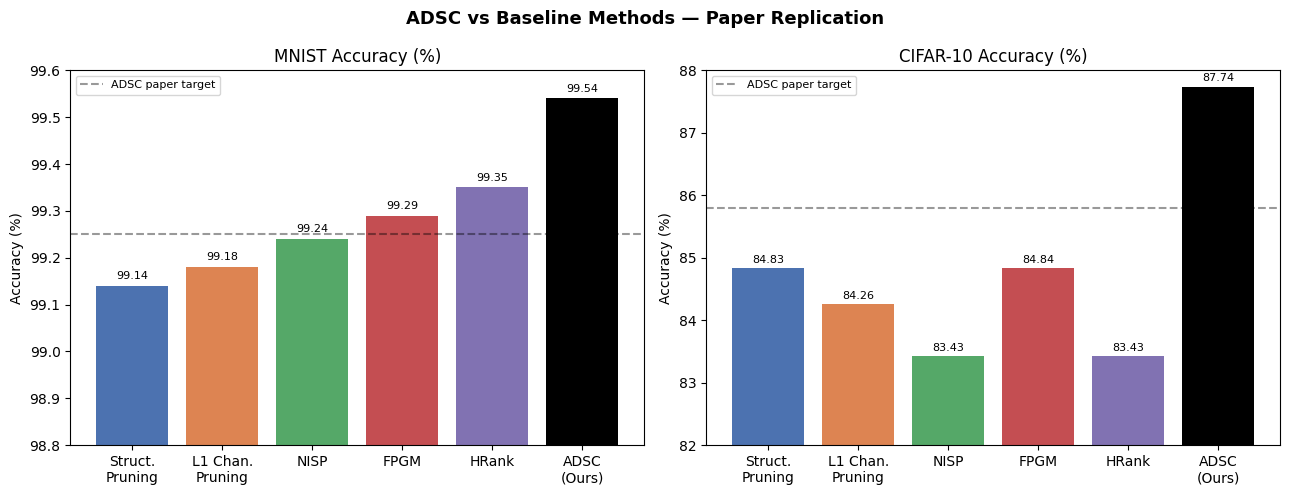

Plot saved as adsc_results.png


In [12]:
import matplotlib.pyplot as plt

# Data from paper Tables 4, 5, 6 vs our run
methods = ['Struct.\nPruning', 'L1 Chan.\nPruning', 'NISP', 'FPGM', 'HRank', 'ADSC\n(Ours)']

# MNIST accuracy
mnist_acc = [99.14, 99.18, 99.24, 99.29, 99.35, student_acc]
# CIFAR-10 accuracy
cifar10_acc = [84.83, 84.26, 83.43, 84.84, 83.43, s_acc_c10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ADSC vs Baseline Methods — Paper Replication", fontsize=13, fontweight='bold')

colors = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2','#000000']

ax = axes[0]
bars = ax.bar(methods, mnist_acc, color=colors)
ax.set_ylim(98.8, 99.6)
ax.set_title("MNIST Accuracy (%)")
ax.set_ylabel("Accuracy (%)")
for bar, val in zip(bars, mnist_acc):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
            ha='center', va='bottom', fontsize=8)
ax.axhline(99.25, color='black', linestyle='--', alpha=0.4, label='ADSC paper target')
ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar(methods, cifar10_acc, color=colors)
ax.set_ylim(82, 88)
ax.set_title("CIFAR-10 Accuracy (%)")
ax.set_ylabel("Accuracy (%)")
for bar, val in zip(bars, cifar10_acc):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05, f'{val:.2f}',
            ha='center', va='bottom', fontsize=8)
ax.axhline(85.79, color='black', linestyle='--', alpha=0.4, label='ADSC paper target')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('adsc_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as adsc_results.png")

In [15]:
# Save MNIST models
torch.save(teacher.state_dict(), 'teacher_mnist.pt')
torch.save(student.state_dict(), 'student_mnist.pt')
print("MNIST Teacher and Student models saved.")

# Save CIFAR-10 models
torch.save(teacher_c10.state_dict(), 'teacher_cifar10.pt')
torch.save(student_c10.state_dict(), 'student_cifar10.pt')
print("CIFAR-10 Teacher and Student models saved.")

# Save California Housing models
torch.save(teacher_reg.state_dict(), 'teacher_housing_reg.pt')
torch.save(student_reg.state_dict(), 'student_housing_reg.pt')
print("California Housing Teacher and Student models saved.")

MNIST Teacher and Student models saved.
CIFAR-10 Teacher and Student models saved.
California Housing Teacher and Student models saved.
